# 2024 Exam set

In [67]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as snb
from scipy.optimize import minimize
from scipy.stats import norm
import jax
import scipy

# use 64-bit precision
from jax import config
config.update("jax_enable_x64", True)

snb.set_style('darkgrid')
snb.set_theme(font_scale=1.1)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [68]:
w_map = jnp.array([2.647, -1.688, -0.596])
sigmoid = lambda x: 1/(1 + jnp.exp(-x))

In [69]:
x_pred = -3
x_pred_vec = jnp.array([x_pred**i for i in range(0, 3)])
x_pred_vec
sigmoid(w_map.T @ x_pred_vec)

Array(0.91269548, dtype=float64)

[[ 3.   -0.39 -0.3 ]
 [-0.39  1.55  0.37]
 [-0.3   0.37  0.14]]
2.647
[-0.20197005  5.49597005]
(np.float64(0.0), np.float64(0.25))


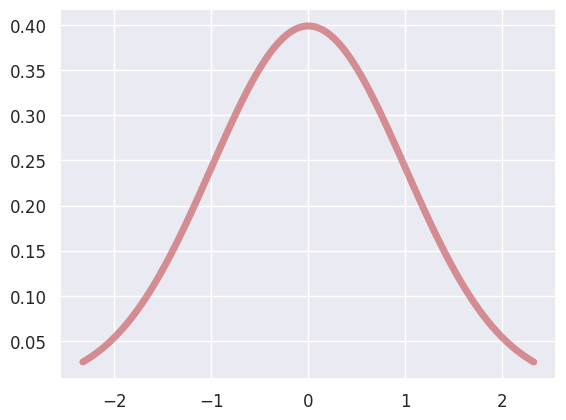

In [70]:
# 3.3 Laplace approximation.
S = jnp.array([3. , -0.39, -0.3, \
                -0.39, 1.55, 0.37, \
                -0.3, 0.37, 0.14]).reshape(3,3)
print(S)
# Compute the posterior credibility interval.
# Simple in this case where we have no data. 
# It is simply just the credibility interval for the gaussian.

print(w_map[0])
#scipy.stats.norm.cdf((-0,), loc = )
print(scipy.stats.norm.ppf((0.05, 0.95), loc = w_map[0], scale = jnp.sqrt(S[0,0])))
print(scipy.stats.norm.stats(scale = 0.5))


x = jnp.linspace(norm.ppf(0.01),
                norm.ppf(0.99), 100)
plt.plot(x, norm.pdf(x),
       'r-', lw=5, alpha=0.6, label='norm pdf')

(array([   8.,   57.,  428., 1363., 2726., 3006., 1693.,  591.,  117.,
          11.]),
 array([-6.91094559, -5.10883377, -3.30672194, -1.50461012,  0.2975017 ,
         2.09961352,  3.90172535,  5.70383717,  7.50594899,  9.30806081,
        11.11017264]),
 <BarContainer object of 10 artists>)

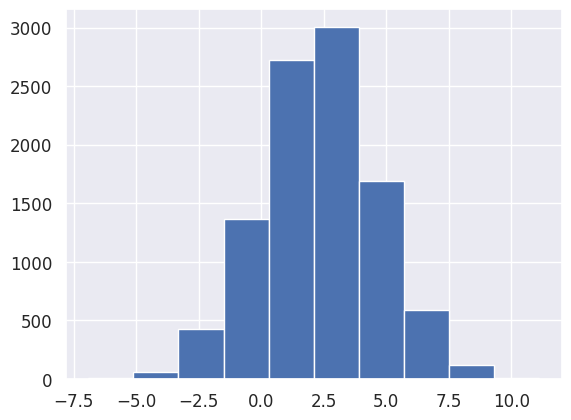

In [71]:
# 3.4 
# In this case it is easier with samples.
N = 10000
key = jax.random.key(0)
L = jnp.linalg.cholesky(S + 1e-20)
zs = jax.random.normal(key, shape=(3, N))
w_samples = L @ zs + jnp.expand_dims(w_map,(1))
f_samples = w_samples.T @ x_pred_vec 

plt.hist(f_samples)

    


2.3469999999999995 5.250000000000002
0.799700110927398


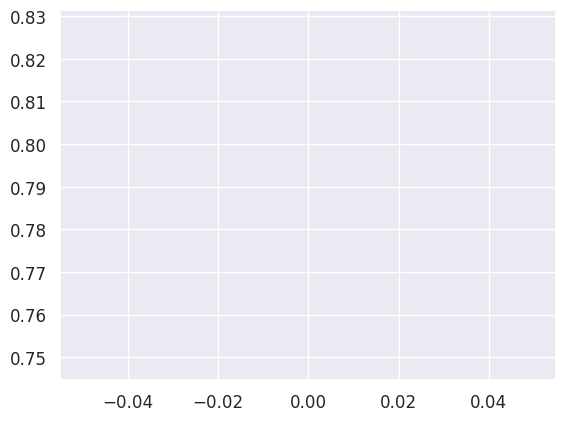

In [72]:
L_pos_mean = w_map
L_pos_cov = S
# Linear gaussian system
m = x_pred_vec@L_pos_mean
v = x_pred_vec.T @ L_pos_cov @ x_pred_vec
import math
probit = lambda x: norm.cdf(x)
p = probit(m/(jnp.sqrt(8/math.pi + v)))
plt.plot(norm.cdf(p))
print(m, v)
print(p)
# Simply just bernoulli of this specific x_star. I could plot the probit accross many x_star to get a continuous plot.

In [73]:
# 3.5

p_y_star = 0.129
U = jnp.array([2, 1, 1, 2]).reshape(2,2)
p = jnp.array([1 - p_y_star, p_y_star])
p.T @ U
# Conclusion is to predict that y star is 0, 
# since it is overwhelmingly likely that y_star is 0.

Array([1.871, 1.129], dtype=float64)

In [74]:
# Part 4
# Mean field approximation. Two independent normals


# Answering the 2024 exam

# Part 1
Solution to Q1.1 through Q1.3: See handwritten solution on appendix A

# Part 2


In [75]:
from exam_utils import *

Solution to Q2.1 through Q1.3: See handwritten solution on appendix B

-6.651211417518849


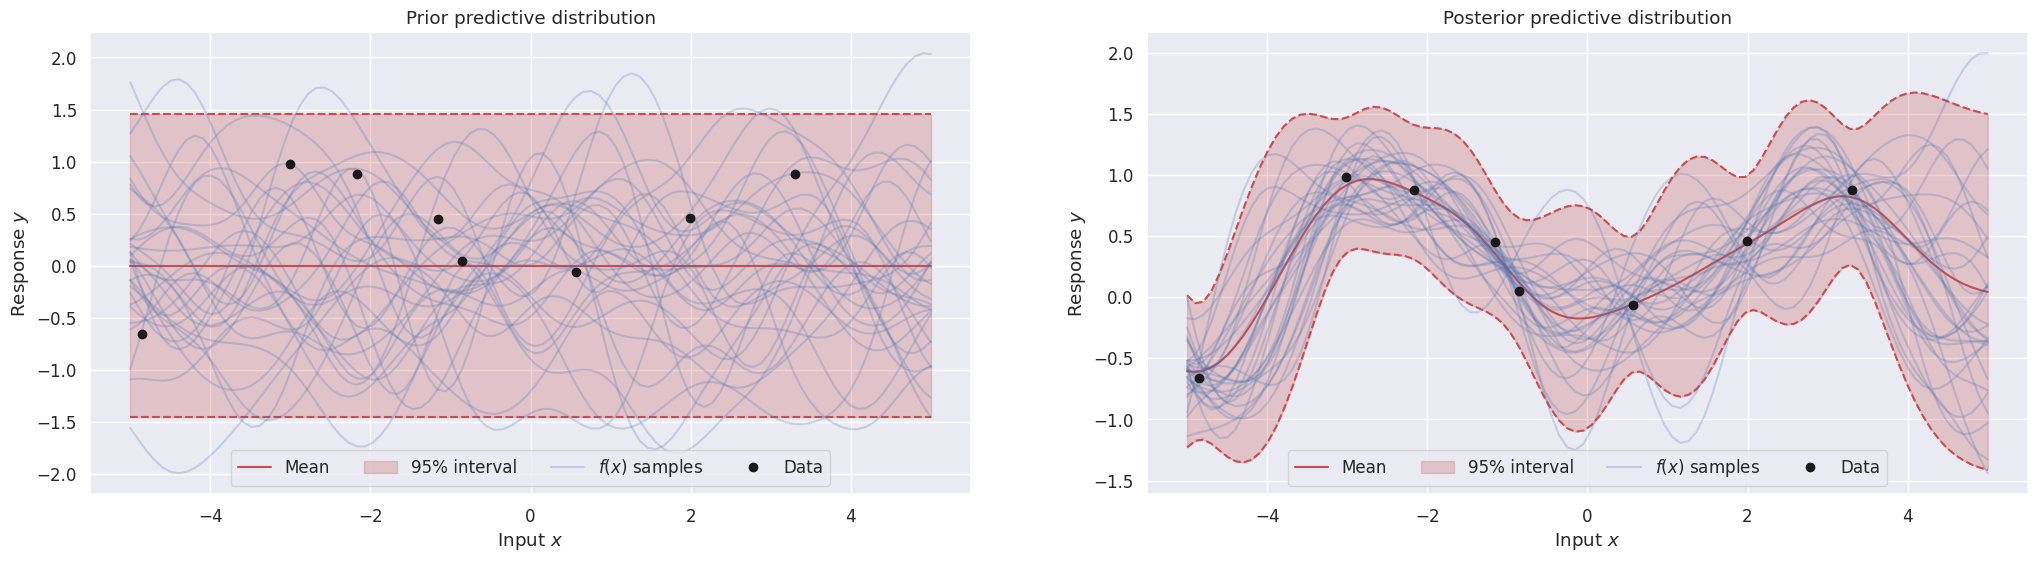

In [76]:
x = jnp.array([-2.17, 1.99, 0.57, -3.01, -1.16, 3.30, -4.85, -0.86])
y = jnp.array([0.88, 0.46, -0.06, 0.98, 0.45, 0.88, -0.66, 0.05])

x = jnp.expand_dims(x, 1)
y = jnp.expand_dims(y, 1)

kappa = 0.7
l = 1/2 * math.sqrt(2)
sigma = 1/5


hyper = Hyperparameters(kappa, l, sigma)

kernel = StationaryIsotropicKernel(squared_exponential)
GPReg = GaussianProcessRegression(x, y, kernel, hyper)
print(GPReg.log_marginal_likelihood(hyper)) # Q2.4

Xstar = jnp.linspace(-5, 5, 100)[:, None]

plot_with_uncertainty(kernel, hyper, x, y, Xstar)

# 2.6
# No and No

# 2.7




In [77]:
from exam_utils import *

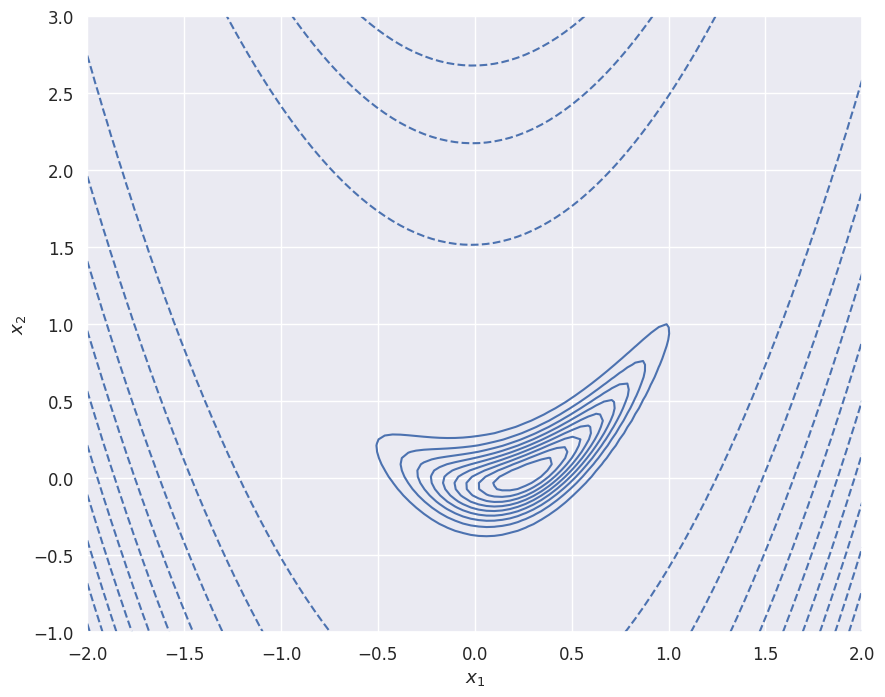

In [78]:
# Part 5 Markov Chain Monte Carlo
C = 100
log_pos = lambda z1, z2 : -(1 - z1)**2 - 20*(z2 - z1**2)**2 -z1**2 - z2*2
fig, ax = plt.subplots(1, 1, figsize = (10,8))
z1star = jnp.linspace(-2, 2, 100)
z2star = jnp.linspace(-1, 3, 100)
plot_contour(ax, log_pos, z1star, z2star, transform= lambda x: x)
plot_contour(ax, log_pos, z1star, z2star, transform= lambda x: jnp.exp(x)) # Plot this not the log density


# grid = Grid2D(z1star, z2star, log_pos)
# fig, ax = plt.subplots(1, 1, figsize=(6, 4))
# grid.plot_contours(ax, f=np.exp)
# ax.set(xlabel='$z_1$', ylabel='$z_2$', title='Contours of posterior density');

In [ ]:
# Q5.2
def log_pos_MCMC(theta):
    z1, z2 = theta[0], theta[1]
    return log_pos(z1, z2)

iterations = int(1e4)
theta_init = jnp.array([0, 1.5])
#theta_init = jnp.array([-5, 50])
thetas = metropolis(log_pos_MCMC, 2, 1, iterations, theta_init, seed = 1)
thetas = HMC(log_pos_MCMC, iterations, theta_init, seed = 1)
thetas = thetas[iterations//10:]


HMC done: accept_rate=0.085  t=6.3s
   1000/10000  accept_rate=0.944  t=1.0s
   2000/10000  accept_rate=0.940  t=1.8s
   3000/10000  accept_rate=0.945  t=2.6s
   4000/10000  accept_rate=0.947  t=3.5s
   5000/10000  accept_rate=0.945  t=4.2s
   6000/10000  accept_rate=0.947  t=5.0s
   7000/10000  accept_rate=0.947  t=5.8s
   8000/10000  accept_rate=0.947  t=6.6s
   9000/10000  accept_rate=0.947  t=7.4s
  10000/10000  accept_rate=0.948  t=8.2s
HMC done: accept_rate=0.948  t=8.2s


(9001, 2)


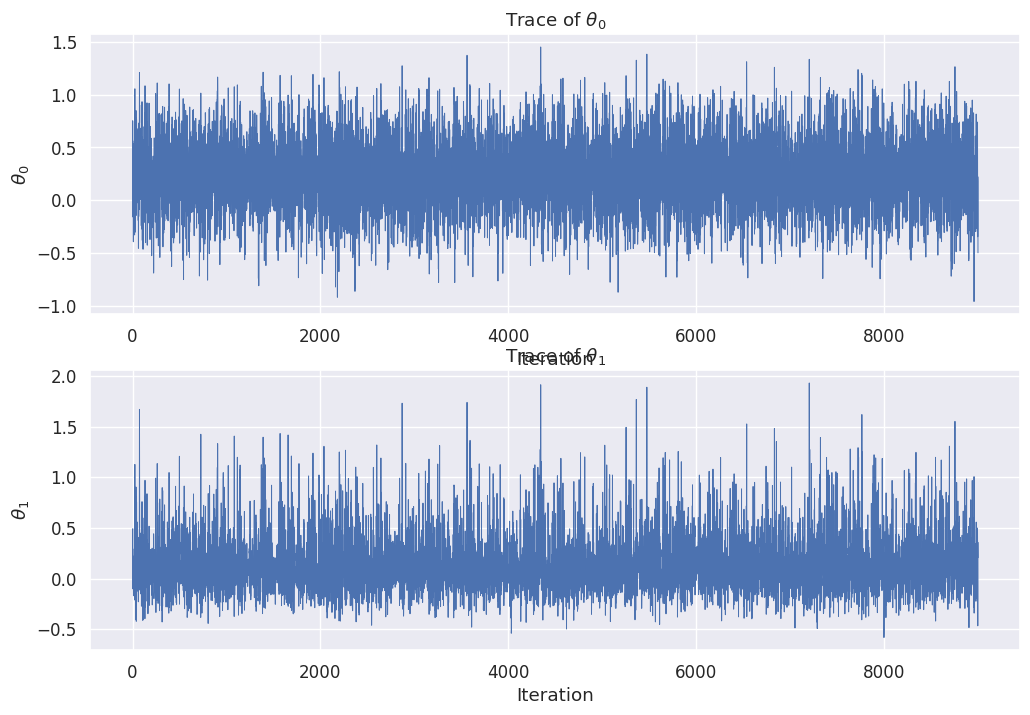

In [80]:
print(thetas.shape)
fig, ax = plt.subplots(2, 1, figsize = (12, 8))
plot_trace(ax, thetas)

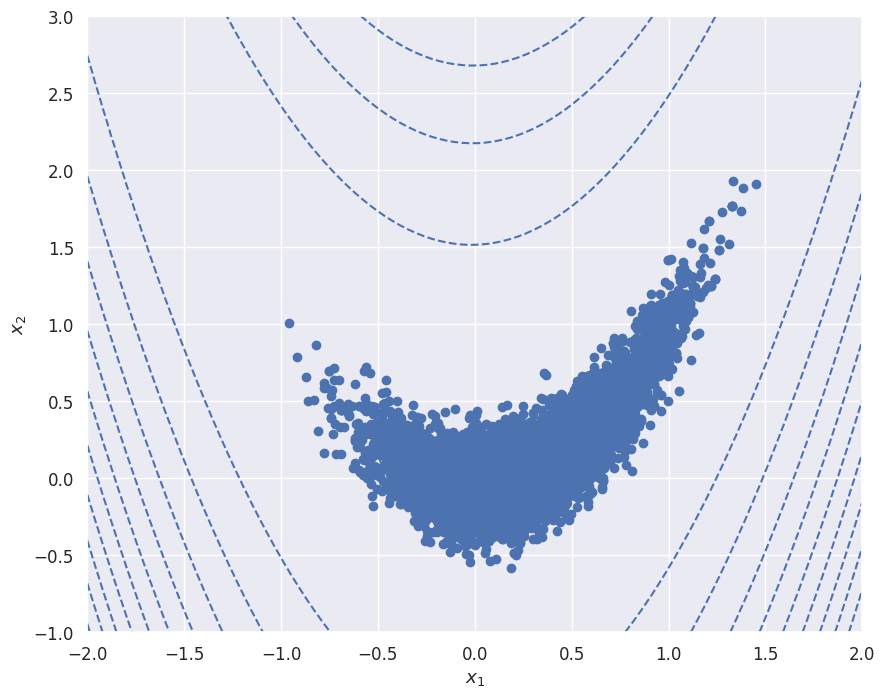

In [81]:
fig, ax = plt.subplots(1, 1, figsize = (10,8))
plot_contour(ax, log_pos, z1star, z2star, transform= lambda x: x)
plot_contour(ax, log_pos, z1star, z2star, transform= lambda x: jnp.exp(x)) # Plot this not the log density
ax.scatter(thetas[:,0], thetas[:,1])

0.08714687482579453


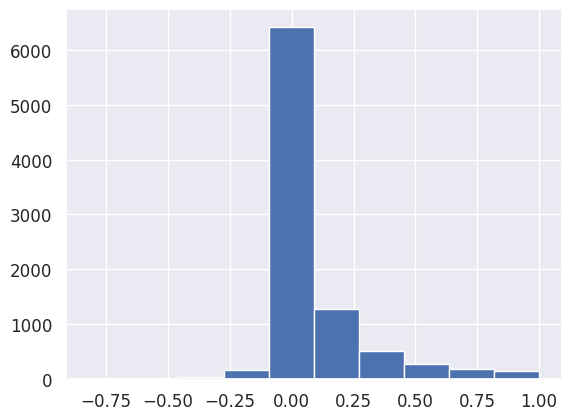

E[sin(z1z2|D)] = 0.09
0.7380291


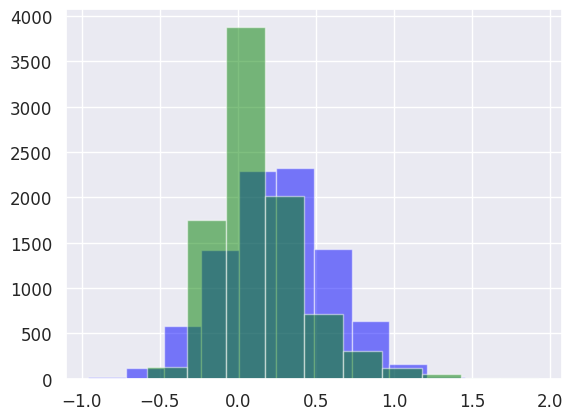

In [82]:
# Q5.3 With or without warmup? I would assume without but it is unclear. 
z1z2 = thetas[:,0] * thetas[:,1]
sin = jnp.sin(z1z2)
plt.hist(sin)
print(sin.mean())
plt.show()

z1, z2 = thetas[:, 0], thetas[:, 1]
mean_sin = np.mean(np.sin(z1*z2), 0)
print(f'E[sin(z1z2|D)] = {mean_sin:3.2f}')

plt.hist(thetas[:,0], color="blue", alpha=0.5)
plt.hist(thetas[:,1], color="green", alpha=0.5)

print((thetas[:,0] > thetas[:,1]).mean())
